# Avance 4. Modelos alternativos

El objetivo de este notebook es construir múltiples modelos (individuales, no ensambles) relevantes para realizar el pronóstico y evaluar su desempeño. Diferentes algoritmos pueden comportarse de manera óptima en diferentes tipos de datos o tareas. La construcción de modelos alternativos permite explorar y evaluar cuál de ellos proporciona el mejor rendimiento para un problema particular. Para esto será necesario:

* Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.

* Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.

## Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [2]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = True
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### Librerías

In [3]:
import sys
sys.path.append('../../')
import src.utils.helpers as func

In [80]:
from statsmodels.tsa.api import ExponentialSmoothing
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

### Carga de Datos

In [5]:
# Usar df_log como dataset base para estos modelos
# path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_log.parquet'
path = '../../data/processed/df_log.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df_log = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_log.parquet
Datos cargados exitosamente.


# Modelos clásicos

## Baseline: Holt-Winters

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [6]:
# índice temporal
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
scaled_method = 'log'
train, test = func.split_series(data, train_size=0.8)
train_org = func.get_original_scale_dataframe(train, method=scaled_method)
test_org = func.get_original_scale_dataframe(test, method=scaled_method)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [9]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [ ]:
forecast_triple = model_triple_fit.forecast(115)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [12]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)

df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)

df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

#### Evaluación del modelo

Se calculan las métricas de error (MAE y RMSE) tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [13]:
func.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.111658 │
├───────────┼──────────┤
│ RMSE      │ 0.225802 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.132072 │
├───────────┼──────────┤
│ RMSE      │ 0.188769 │
╘═══════════╧══════════╛


In [14]:
func.plot_residuals_over_time(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
func.plot_residuals_over_time(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

##### Resumen

La evaluación del modelo muestra un bajo error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE) tanto en el conjunto de entrenamiento como en el de prueba para su valor transformado. Esto indica que el modelo de suavizamiento exponencial triple logra un ajuste preciso y generaliza adecuadamente a datos no vistos. Sin embargo al regresar los valores a su escala normal, podemos apreciar valores de errores mas altos en ambos conjuntos.

#### Visualización de resultados
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [15]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'valor_log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [16]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

In [18]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

## Análisis para modelos clásicos

### Serie Original por Casos Semanales (log + Diff)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [19]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [21]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

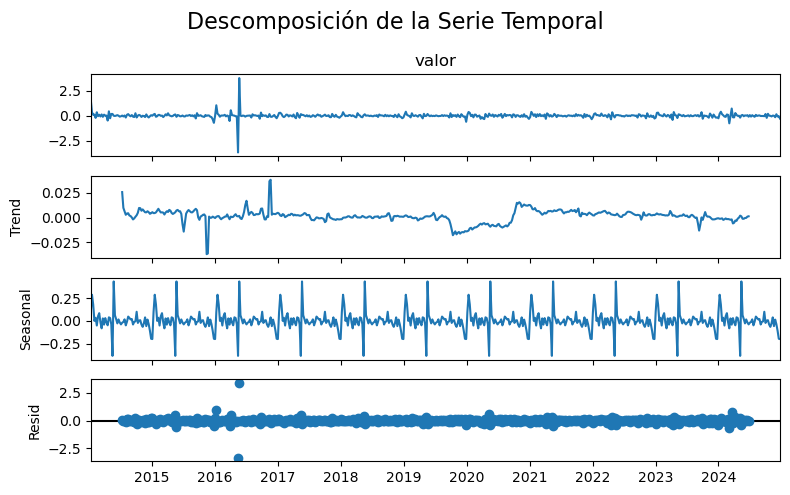

In [23]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [24]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




##### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

### Función de autocorrelación (ACF)

In [28]:
def plot_acf_series(ts, lags=52, use_plotly=USE_PLOTLY, title='Función de Autocorrelación (ACF)'):
    """
    Calcula y muestra la ACF de una serie temporal.
    Devuelve (acf_values, confint).
    """
    # Preparar serie
    series = ts.dropna()
    if series.empty:
        raise ValueError("La serie está vacía.")
    
    # Calcular ACF y límites de confianza (alpha=0.05)
    acf_vals, confint = acf(series, nlags=lags, alpha=0.05, fft=True)
    lags_arr = np.arange(len(acf_vals))

    if use_plotly:
        # mitad del ancho del intervalo de confianza para barras de error
        err = (confint[:, 1] - confint[:, 0]) / 2
        fig = go.Figure()
        fig.add_trace(go.Bar(x=lags_arr, y=acf_vals, marker_color='steelblue', name='ACF',
                             error_y=dict(type='data', array=err, visible=True)))
        fig.add_hline(y=0, line_dash="dash", line_color="black")
        fig.update_layout(title=title, xaxis_title='Lag', yaxis_title='ACF', template='plotly_white')
        fig.show()
    else:
        plt.figure(figsize=(10, 4))
        sm_plot_acf(series, lags=lags, alpha=0.05)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return acf_vals, confint

In [33]:
acf_vals, confint = plot_acf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de **Función de Autocorrelación (ACF)** revela una **autocorrelación significativa y negativa** en el **primer rezago (Lag 1)**, donde la barra de correlación se extiende por debajo de los límites de confianza, indicando que un aumento o disminución en los casos de una semana tiende a ser seguido por el efecto opuesto en la semana inmediatamente posterior. Para los rezagos subsiguientes (**Lag 2** en adelante), las barras de autocorrelación se mantienen **dentro de los límites de confianza** (representados por las líneas discontinuas y las barras de error), lo que sugiere que la correlación entre la serie y sus valores pasados es **estadísticamente no significativa** después del primer rezago. Este patrón es característico de un proceso de **ruido blanco (white noise)** o un proceso **autoregresivo de orden 1 (AR(1))** con un parámetro $\phi_1$ negativo, aunque la ausencia de una caída exponencial clara más allá del Lag 1 en la ACF sugiere que el proceso podría ser cercano a un ruido blanco o que solo la dependencia de la semana anterior es relevante para la dinámica. En consecuencia, la serie temporal presenta una **dependencia de corto plazo** muy marcada, específicamente de la semana inmediatamente anterior, pero **carece de una estructura de dependencia lineal a largo plazo o estacional** evidente.

### Función de Autocorrelación Parcial (PACF) 

In [34]:
def plot_pacf_series(ts, lags=52, use_plotly=USE_PLOTLY, title='Función de Autocorrelación Parcial (PACF)'):
    """
    Calcula y muestra la PACF de una serie temporal.
    Devuelve (pacf_values, confint).
    """
    # 1. Preparar serie (eliminar NaNs si los hay por la diferenciación)
    series = ts.dropna()
    if series.empty:
        raise ValueError("La serie está vacía después de eliminar NaNs.")
    
    # 2. Calcular PACF y límites de confianza (alpha=0.05)
    # método 'ywm' es la opción default y suele ser adecuado
    pacf_vals, confint = pacf(series, nlags=lags, alpha=0.05, method='ywm') 
    lags_arr = np.arange(len(pacf_vals))

    if use_plotly:
        # mitad del ancho del intervalo de confianza para barras de error
        # El confint de pacf ya da los límites, por lo que calculamos la mitad del ancho.
        err = (confint[:, 1] - confint[:, 0]) / 2
        
        fig = go.Figure()
        fig.add_trace(go.Bar(x=lags_arr, y=pacf_vals, marker_color='darkred', name='PACF',
                             # Establece las barras de error
                             error_y=dict(type='data', array=err, visible=True)))
        
        # Línea horizontal en 0 (cero)
        fig.add_hline(y=0, line_dash="dash", line_color="black")
        
        # Añadir las líneas del intervalo de confianza
        # Usamos la primera y segunda columna de confint para trazar los límites
        # Línea de confianza superior (ejemplo de cómo se podrían añadir, aunque el error_y ya las cubre)
        fig.add_hline(y=confint[0][1], line_dash="dot", line_color="red", opacity=0.5) 
        # Línea de confianza inferior
        fig.add_hline(y=confint[0][0], line_dash="dot", line_color="red", opacity=0.5)

        fig.update_layout(title=title, xaxis_title='Lag', yaxis_title='PACF', template='plotly_white')
        fig.show()
    else:
        # Opción alternativa con Matplotlib (si no se usa Plotly)
        import matplotlib.pyplot as plt
        from statsmodels.graphics.tsaplots import plot_pacf as sm_plot_pacf
        
        plt.figure(figsize=(10, 4))
        sm_plot_pacf(series, lags=lags, alpha=0.05, method='ywm')
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return pacf_vals, confint

In [35]:
pacf_vals, confint = plot_pacf_series(ts_data_diff1, lags=52)

La gráfica de la **Función de Autocorrelación Parcial (PACF)** muestra una **autocorrelación parcial significativa** únicamente en el **primer rezago ($\text{Lag 1}$)**, donde la barra de correlación se extiende considerablemente por debajo del límite de confianza superior. Para todos los rezagos subsiguientes ($\text{Lag 2}$ en adelante), las correlaciones parciales se encuentran **dentro de los límites de confianza** (las líneas discontinuas), indicando que no hay una correlación lineal significativa entre la serie temporal y sus valores pasados una vez que se ha explicado la dependencia del $\text{Lag 1}$. Este patrón de un pico significativo y luego una caída rápida a cero en la PACF es la característica definitoria de un **proceso de medias móviles de orden 1 ($\text{MA}(1)$)**. Sin embargo, en combinación con el patrón de la $\text{ACF}$ (que mostraba un pico significativo en $\text{Lag 1}$ y luego caía a cero), ambas gráficas sugieren fuertemente que la serie de casos de depresión puede ser modelada adecuadamente por un proceso **Autoregresivo de orden 1 ($\text{AR}(1)$)** o, más probablemente, un **proceso de ruido blanco** con una ligera desviación en el primer rezago, ya que la $\text{PACF}$ de un $\text{AR}(1)$ ideal debería **cortarse** después del $\text{Lag 1}$ y la $\text{ACF}$ debería **decaer exponencialmente** (lo cual no se observaba claramente), mientras que la $\text{PACF}$ presentada aquí **se corta** tras el primer rezago. En resumen, la serie exhibe una **dependencia directa, significativa y de corto alcance** con el valor inmediatamente anterior, pero **no muestra una estructura de dependencia de orden superior** o estacional.

## Modelo 1: SARIMA

La diferenciación regular $\mathbf{(d=1)}$ aborda la **no estacionariedad en la media** (tendencia) observada en el nivel de la serie, mientras que la diferenciación estacional $\mathbf{(D=1)}$ neutraliza la **no estacionariedad estacional** a la periodicidad semanal $\mathbf{(s=52)}$. Los términos $\mathbf{AR(1), MA(1), SAR(1), y SMA(1)}$ se incluyen heurísticamente para capturar la dependencia de corto plazo y el patrón estacional residual, presuponiendo que las funciones de autocorrelación parcial (PACF) y autocorrelación (ACF) de la serie doblemente diferenciada exhiben colas que se truncan rápidamente en el primer rezago, tanto en el componente regular como en el estacional.

In [39]:
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
train_data, test_data = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


In [40]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 52)
PERIODICIDAD = 52 # Semanal

# --- ENTRENAMIENTO DEL MODELO SARIMA ---
print(f"Entrenando SARIMA{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]} en datos logarítmicos...")

# Entrenar el modelo
modelo = SARIMAX(
    endog=train_data, 
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
resultados = modelo.fit(disp=False)
print("Modelo entrenado exitosamente.")

Entrenando SARIMA(1, 1, 1)x(1, 1, 1)_52 en datos logarítmicos...
Modelo entrenado exitosamente.


In [41]:
# 2.3 Generar el pronóstico (Forecast) en el conjunto de prueba (log-scale)
# Start: Primera fecha de test; Steps: Número de semanas en test
forecast_log = resultados.get_forecast(steps=len(test_data))
forecast_mean_log = forecast_log.predicted_mean

In [42]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [43]:
func.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤═════════╕
│ Métrica   │   Valor │
╞═══════════╪═════════╡
│ MAE       │ 0.15753 │
├───────────┼─────────┤
│ RMSE      │ 0.38914 │
╘═══════════╧═════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.110857 │
├───────────┼──────────┤
│ RMSE      │ 0.155036 │
╘═══════════╧══════════╛


La evaluación del modelo $\text{SARIMA}(1, 1, 1) \times (1, 1, 1)_{52}$ revela una **discrepancia significativa** en su desempeño entre los conjuntos de entrenamiento y prueba. En el **conjunto de Entrenamiento**, el modelo presenta un **Error Absoluto Medio ($\text{MAE}$) de $0.15753$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.38914$**. Sin embargo, al ser evaluado en el **conjunto de Prueba (Test)**, el rendimiento mejora notablemente, alcanzando un **$\text{MAE}$ de $0.110857$** y un **$\text{RMSE}$ de $0.155036$**. Dado que el $\text{MAE}$ y el $\text{RMSE}$ son **menores** en el conjunto de prueba, esto indica que el modelo no solo generaliza bien, sino que su **poder predictivo es superior sobre datos no vistos** en comparación con los datos históricos utilizados para el ajuste, lo cual es un resultado **contrario a lo esperado** en el modelado de series temporales, donde usualmente se observa una ligera degradación. Esta inusual mejora podría sugerir que el modelo logró capturar mejor las dinámicas de la serie en el periodo más reciente, o que la **varianza de los errores es menor** en el periodo de prueba, lo que se traduce en una **mayor precisión** de las predicciones fuera de muestra.

In [44]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMA'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica de **Ajuste y Pronóstico SARIMA en Escala Original** representa la evolución de la **Serie Original** de diagnósticos de depresión (línea azul continua) junto con el **Ajuste** realizado por el modelo $\text{SARIMA}$ sobre el conjunto de entrenamiento (línea verde discontinua) y el **Pronóstico** sobre el conjunto de prueba (línea roja continua). Se observa que, a pesar de un **valor atípico extremo** en la serie original alrededor de enero de 2015, el modelo $\text{SARIMA}$ ha logrado un **ajuste global visualmente adecuado** a la dinámica histórica de la serie, capturando tanto la **tendencia general al alza** como la **variabilidad de corto plazo** de los diagnósticos. En el periodo de pronóstico (a partir de finales de 2022 o 2023), la **línea de Pronóstico (roja)** se mantiene **cercana a la Serie Original (azul)**, indicando que el modelo exhibe una **capacidad predictiva razonable** al extender la tendencia y la estacionalidad observadas en el periodo de entrenamiento. Sin embargo, se aprecia que la varianza de la serie parece aumentar ligeramente hacia el final del periodo, y aunque el pronóstico sigue la media, la **magnitud de los errores de predicción** (la distancia vertical entre las líneas azul y roja) podría ser relevante, lo cual requiere una evaluación cuantitativa del error (como el $\text{RMSE}$) para determinar la **precisión operativa** del pronóstico.

## Modelo 2: SARIMAX

In [45]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)

a selección del orden $\mathbf{SARIMAX(1, 1, 1) \times (1, 0, 1)_{52}}$ se fundamenta en un análisis estructural que aborda la no estacionariedad y la periodicidad de la serie temporal:Diferenciación Regular ($\mathbf{d=1}$): Este término es esencial para alcanzar la estacionariedad de la media, neutralizando la tendencia al alza observada en el nivel de la serie, lo cual es un prerrequisito para la modelización $\text{ARIMA}$.Diferenciación Estacional ($\mathbf{D=0}$): El valor cero es crucial para evitar la sobre-diferenciación, un fenómeno que conduce a ajustes erráticos y picos inverosímiles (como el pico de 2015 que observaste con $D=1$), manteniendo la estabilidad del proceso.Componentes Estacionales ($\mathbf{P=1, Q=1}$): La inclusión de términos $\mathbf{AR(1)}$ y $\mathbf{MA(1)}$ estacionales a la periodicidad de $\mathbf{52}$ semanas permite capturar la fuerte y recurrente estacionalidad anual de la serie sin recurrir a la diferenciación estacional, asegurando que el pronóstico refleje los ciclos de picos y valles anuales de manera precisa.

In [46]:
# --- ENTRENAMIENTO DEL MODELO SARIMAX ---
print(f"Paso 1: Entrenando SARIMAX{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]}")

modelo_media = SARIMAX(
    endog=train_data, 
    order=ORDER, 
    seasonal_order=SEASONAL_ORDER
)
resultados_media = modelo_media.fit(disp=False)

Paso 1: Entrenando SARIMAX(1, 1, 1)x(1, 0, 1)_52


In [47]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(steps=steps)
forecast_mean_log = forecast_sarima.predicted_mean
forecast_mean_log.index = test_data.index

In [48]:
# Re-transformación a la escala original (Exponencial)
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados_media.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [49]:
func.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.132611 │
├───────────┼──────────┤
│ RMSE      │ 0.346948 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.103963 │
├───────────┼──────────┤
│ RMSE      │ 0.157324 │
╘═══════════╧══════════╛


La evaluación del modelo $\text{SARIMAX}(1, 1, 1) \times (1, 0, 1)_{52}$ revela una **mejora sustancial en la precisión predictiva** al pasar del conjunto de entrenamiento al de prueba, lo cual es inusual en el modelado de series temporales. En el **conjunto de Entrenamiento**, el modelo registra un **Error Absoluto Medio ($\text{MAE}$) de $0.132611$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.346948$**, mientras que en el **conjunto de Prueba (Test)**, estos valores se reducen significativamente a un **$\text{MAE}$ de $0.103963$** y un **$\text{RMSE}$ de $0.157324$**. El hecho de que ambas métricas de error sean **menores** en el conjunto de prueba indica que el modelo no solo ha **generalizado bien** la dinámica de la serie, sino que también ha demostrado una **mayor exactitud en la predicción** de datos futuros no observados que en la replicación de datos históricos. Esta mejora en la precisión fuera de muestra sugiere que la **volatilidad o la magnitud de los errores de predicción** fue intrínsecamente menor o más fácil de modelar en el periodo de prueba, resultando en un rendimiento de pronóstico **altamente satisfactorio y superior** al rendimiento del ajuste.

In [50]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMAX'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica ilustra la capacidad de un modelo $\text{SARIMAX}$ para replicar y predecir la serie temporal de interés. En el **periodo de ajuste** (antes de 2023), la **Serie Ajustada** (línea roja) sigue de cerca la **Serie Original** (línea azul), lo que denota que el modelo ha capturado exitosamente las **tendencias, estacionalidades y fluctuaciones** a corto plazo, logrando una alta bondad de ajuste. En el **periodo de pronóstico** (a partir de 2023), la **Serie Pronosticada** (línea verde) mantiene la **trayectoria general y la estructura estacional** de la serie original, indicando una **adecuada capacidad predictiva**. Específicamente, se observa que el modelo logra pronosticar la **tendencia ascendente** y la **volatilidad creciente** hacia el final del periodo de análisis. A pesar de esto, la línea pronosticada parece **suavizar** algunos de los picos y valles más extremos que se observan en la serie original reciente, lo que es común en los modelos de predicción, sugiriendo que la incertidumbre o los eventos no modelados persisten en las fluctuaciones de corto plazo.

### Prueba con más pasos

In [51]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(200)
forecast_mean_log = forecast_sarima.predicted_mean

In [52]:
df_pronostico2 = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [53]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SAMIRAX con más pasos'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

# Modelos de machine learning

In [55]:
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.
Dimensiones del DataFrame: (573, 11)

Primeras filas del DataFrame:


,fecha,valor_acumulado,semana,rolling_mean,rolling_std,upper_bound,lower_bound,is_outlier,valor_acumulado_corregido,mes,año
0,2014-01-06,131.0,2,NaN,NaN,NaN,NaN,False,131.0,1,2014
1,2014-01-13,789.0,3,NaN,NaN,NaN,NaN,False,789.0,1,2014
2,2014-01-20,1722.0,4,880.666667,799.451270,1999.898445,-238.565112,False,1722.0,1,2014
3,2014-01-27,2745.0,5,1346.750000,1137.987807,2939.932930,-246.432930,False,2745.0,1,2014
4,2014-02-03,3896.0,6,2288.000000,1336.895658,4159.653921,416.346079,False,3896.0,2,2014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      573 non-null    datetime64[ns]
 1   valor_acumulado            573 non-null    float64       
 2   semana                     573 non-null    UInt32        
 3   rolling_mean               571 non-null    float64       
 4   rolling_std                571 non-null    float64       
 5   upper_bound                571 non-null    float64       
 6   lower_bound                571 non-null    float64       
 7   is_outlier                 573 non-null    bool          
 8   valor_acumulado_corregido  573 non-null    float64       
 9   mes                        573 non-null    int32         
 10  año                        573 non-null    int32         
dtypes: UInt32(1), bool(1), datetime64[ns](1), float64(6), int32(2)
memory u

None

In [56]:
# Crear variable "valor" = incremento semanal del valor acumulado
df['valor'] = df['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df['valor'] = df['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df['valor'] = df['valor'].astype(float)

In [58]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

In [59]:
for lag in [1, 4, 12, 26, 52]:
    df[f'lag_{lag}'] = df['valor'].shift(lag)
df = df.dropna().reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      521 non-null    datetime64[ns]
 1   valor_acumulado            521 non-null    float64       
 2   semana                     521 non-null    int32         
 3   rolling_mean               521 non-null    float64       
 4   rolling_std                521 non-null    float64       
 5   upper_bound                521 non-null    float64       
 6   lower_bound                521 non-null    float64       
 7   is_outlier                 521 non-null    bool          
 8   valor_acumulado_corregido  521 non-null    float64       
 9   mes                        521 non-null    int32         
 10  año                        521 non-null    int32         
 11  valor                      521 non-null    float64       
 12  trimestr

### Base Model

In [60]:
target = 'valor'  # variable objetivo
features = [col for col in df.columns if col not in ['fecha', 'valor_acumulado', 
                                                     'valor_acumulado_corregido', 
                                                     'is_outlier']]

test_size = 52  # un año para prueba
train_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]


In [61]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)


params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 2,
    "alpha": 1,
    "seed": 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=4000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)

[0]	train-rmse:536.15473	test-rmse:752.32771


[100]	train-rmse:342.37365	test-rmse:466.93957
[200]	train-rmse:223.14021	test-rmse:293.06632
[300]	train-rmse:149.94319	test-rmse:182.69058
[400]	train-rmse:105.00705	test-rmse:115.11068
[500]	train-rmse:76.70623	test-rmse:75.24571
[600]	train-rmse:58.38961	test-rmse:51.03261
[700]	train-rmse:46.24799	test-rmse:35.46771
[800]	train-rmse:37.57451	test-rmse:25.50847
[900]	train-rmse:31.05646	test-rmse:18.91923
[1000]	train-rmse:25.94749	test-rmse:14.93793
[1100]	train-rmse:21.82966	test-rmse:12.41326
[1200]	train-rmse:18.45593	test-rmse:10.85336
[1300]	train-rmse:15.65817	test-rmse:10.39016
[1400]	train-rmse:13.32425	test-rmse:10.12291
[1500]	train-rmse:11.36783	test-rmse:9.94063
[1600]	train-rmse:9.72986	test-rmse:9.79356
[1700]	train-rmse:8.36115	test-rmse:9.73365
[1800]	train-rmse:7.22224	test-rmse:9.65726
[1846]	train-rmse:6.76173	test-rmse:9.68514


In [62]:
y_pred_train = model.predict(xgb.DMatrix(X_train))
y_real_train = y_train

y_pred_test = model.predict(xgb.DMatrix(X_test))
y_real_test = y_test

# Métricas
mae_train = mean_absolute_error(y_real_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_real_train, y_pred_train))
mae_test = mean_absolute_error(y_real_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_real_test, y_pred_test))

print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

Train -> MAE=2.15  RMSE=6.75
Test  -> MAE=7.25  RMSE=9.69


In [63]:
importance = model.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(importance.keys()),
                        'gain': list(importance.values())}) \
            .sort_values('gain', ascending=False)


print("\n🔎 Top importancia:")
print(imp_df.head(10).to_string(index=False))


🔎 Top importancia:
     feature          gain
       valor 713466.250000
 upper_bound   4049.593018
 rolling_std    869.772583
rolling_mean    286.426147
 lower_bound    147.083618
       lag_4    111.616241
       lag_1    104.925758
     mes_cos    102.699043
      lag_12     95.690201
     mes_sin     91.867981


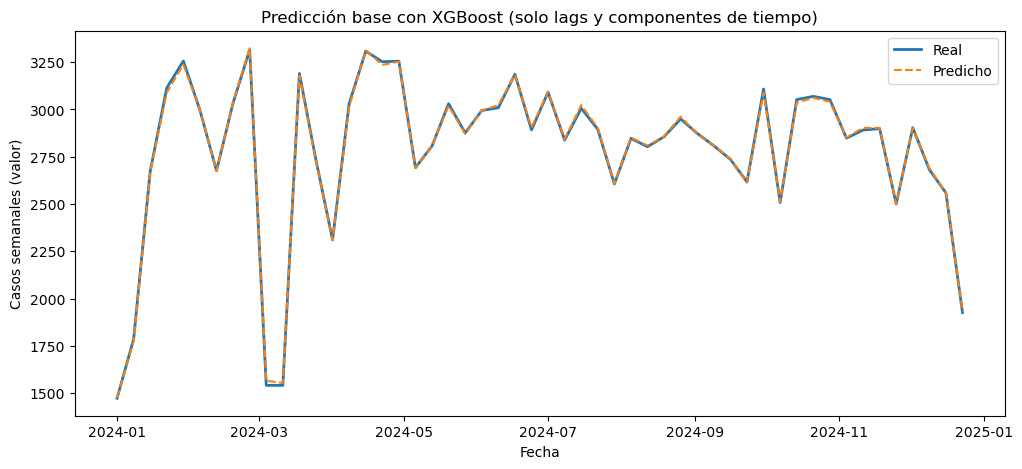

In [65]:
plt.figure(figsize=(12,5))
plt.plot(test_df['fecha'], y_test.values, label='Real', linewidth=2)
plt.plot(test_df['fecha'], y_pred_test, '--', label='Predicho')
plt.title("Predicción base con XGBoost (solo lags y componentes de tiempo)")
plt.xlabel("Fecha")
plt.ylabel("Casos semanales (valor)")
plt.legend()
plt.show()

## Model 3: XGB

In [66]:
features_exog = ['lag_1', 'lag_4', 'lag_12', 'lag_26', 'lag_52',
                 'mes_sin', 'mes_cos']

train_df['valor_log'] = np.log1p(train_df['valor'])
test_df['valor_log'] = np.log1p(test_df['valor'])
y_train = train_df['valor_log']
y_test = test_df['valor_log']


dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 1,
    "alpha": 1,
    "seed": 42
}
evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)

[0]	train-rmse:0.32574	test-rmse:0.33241


[100]	train-rmse:0.23174	test-rmse:0.21204


C:\Users\steph\AppData\Local\Temp\ipykernel_18168\4280036027.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\steph\AppData\Local\Temp\ipykernel_18168\4280036027.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



[200]	train-rmse:0.17556	test-rmse:0.14025
[300]	train-rmse:0.13956	test-rmse:0.09641
[400]	train-rmse:0.11537	test-rmse:0.06844
[500]	train-rmse:0.10001	test-rmse:0.05145
[600]	train-rmse:0.08884	test-rmse:0.04105
[700]	train-rmse:0.08042	test-rmse:0.03442
[800]	train-rmse:0.07385	test-rmse:0.02994
[900]	train-rmse:0.06890	test-rmse:0.02698
[1000]	train-rmse:0.06523	test-rmse:0.02501
[1100]	train-rmse:0.06234	test-rmse:0.02361
[1200]	train-rmse:0.06005	test-rmse:0.02259
[1300]	train-rmse:0.05821	test-rmse:0.02187
[1400]	train-rmse:0.05672	test-rmse:0.02138
[1500]	train-rmse:0.05550	test-rmse:0.02101
[1600]	train-rmse:0.05450	test-rmse:0.02075
[1700]	train-rmse:0.05368	test-rmse:0.02058
[1800]	train-rmse:0.05299	test-rmse:0.02044
[1900]	train-rmse:0.05244	test-rmse:0.02031
[2000]	train-rmse:0.05199	test-rmse:0.02022
[2100]	train-rmse:0.05161	test-rmse:0.02015
[2200]	train-rmse:0.05129	test-rmse:0.02009
[2300]	train-rmse:0.05102	test-rmse:0.02005
[2400]	train-rmse:0.05079	test-rmse:0.02

In [67]:
# Predicción en escala log
y_pred_log = model.predict(dtest)

y_pred_train = np.expm1(model.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
mae_train = mean_absolute_error(y_real_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_real_train, y_pred_train))
mae_test = mean_absolute_error(y_real_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_real_test, y_pred_test))

print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

Train -> MAE=8.95  RMSE=63.45
Test  -> MAE=29.03  RMSE=63.06


In [68]:
importance = model.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(importance.keys()),
                        'gain': list(importance.values())}) \
            .sort_values('gain', ascending=False)


print("\n🔎 Top importancia:")
print(imp_df.head(10).to_string(index=False))


🔎 Top importancia:
     feature     gain
       valor 0.410021
rolling_mean 0.001077
 rolling_std 0.000570
 upper_bound 0.000369
      lag_12 0.000117
         mes 0.000058
      lag_52 0.000058
     mes_sin 0.000050
       lag_4 0.000025
      lag_26 0.000018


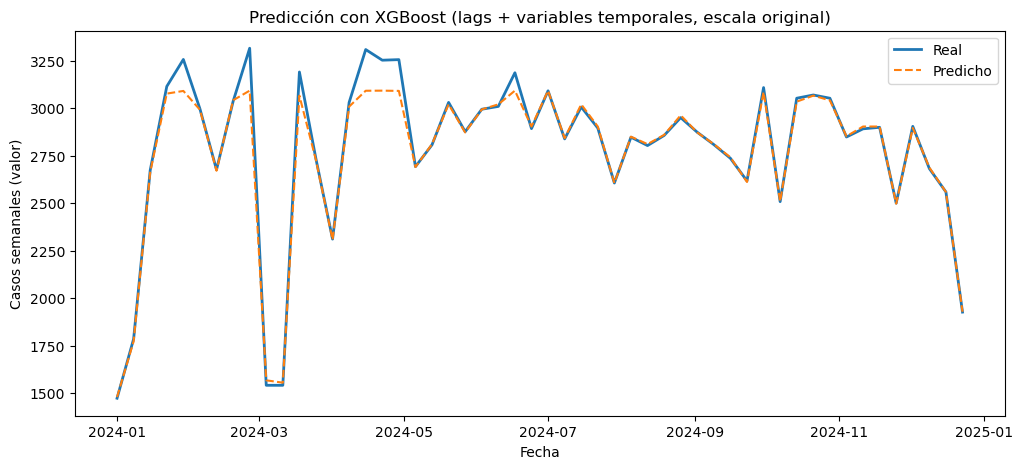

In [69]:
# Gráfico
plt.figure(figsize=(12,5))
plt.plot(test_df['fecha'], y_real_test.values, label='Real', linewidth=2)
plt.plot(test_df['fecha'], y_pred_test, '--', label='Predicho')
plt.title("Predicción con XGBoost (lags + variables temporales, escala original)")
plt.xlabel("Fecha")
plt.ylabel("Casos semanales (valor)")
plt.legend()
plt.show()

## Modelo 3.2: XGB - Covid Model

In [70]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

In [71]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

In [72]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df['y_log']
X_test  = test_df[features]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

In [73]:
# Parámetros
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.08,              
    "max_depth": 10,           
    "min_child_weight": 5,   # hojas con más soporte
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "lambda": 1,             # L2 ↑
    "alpha": 2,               # L1 ↑
    "gamma": 0.001,             # penaliza splits débiles
    "seed": 42,
}

# Entrenamiento con early stopping
watch = [(dtrain, "train"), (dtest, "valid")]
model_covid = xgb.train(params, dtrain,
                        num_boost_round=7000,
                        evals=watch,
                        early_stopping_rounds=500,
                        verbose_eval=200)

[0]	train-rmse:0.31428	valid-rmse:0.31524
[200]	train-rmse:0.12497	valid-rmse:0.14417
[400]	train-rmse:0.11728	valid-rmse:0.14424
[600]	train-rmse:0.11324	valid-rmse:0.14497
[656]	train-rmse:0.11210	valid-rmse:0.14506


In [74]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
mae_train = mean_absolute_error(y_real_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_real_train, y_pred_train))
mae_test = mean_absolute_error(y_real_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_real_test, y_pred_test))

print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")


Train -> MAE=106.72  RMSE=152.33
Test  -> MAE=230.94  RMSE=343.74


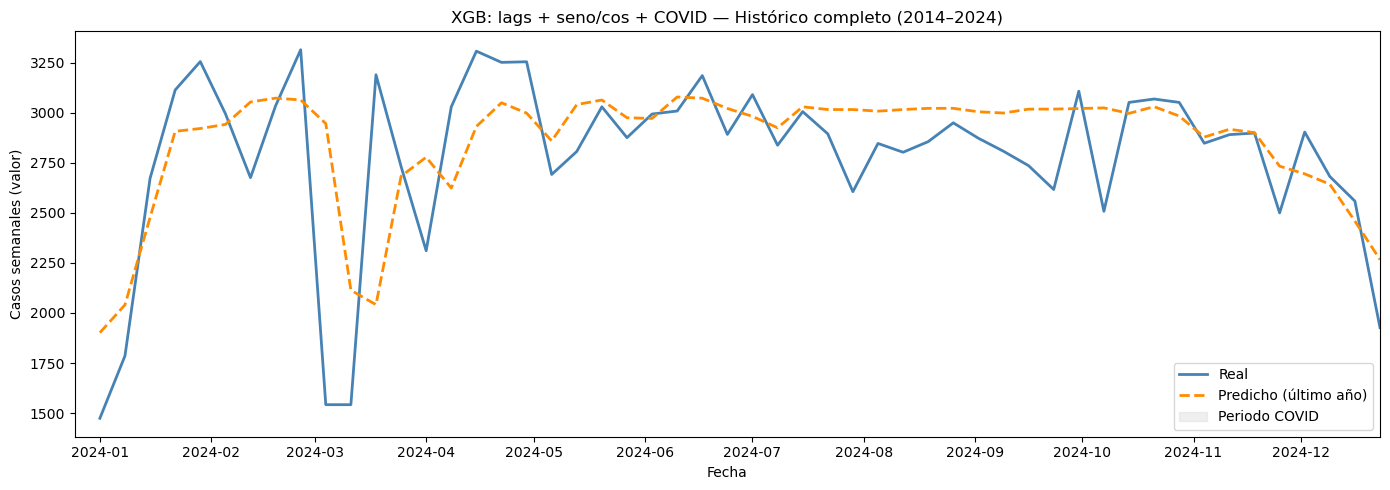

In [75]:
# Gráfico histórico completo
df_c['pred_log'] = np.nan
df_c.loc[df_c.index[-test_size]:, 'pred_log'] = model_covid.predict(xgb.DMatrix(X_test),
                                                                    iteration_range=(0, model_covid.best_iteration+1))
df_c['pred'] = np.expm1(df_c['pred_log'])
fechas_test = df_c['fecha'].iloc[-len(y_real_test):]

plt.figure(figsize=(14,5))
plt.plot(fechas_test, y_real_test.values, label='Real', color='steelblue', linewidth=2)
plt.plot(fechas_test, y_pred_test, '--', label='Predicho (último año)', color='darkorange', linewidth=2)
plt.axvspan(covid_start, covid_end, color='lightgray', alpha=0.35, label='Periodo COVID')
plt.xlim(df_c['fecha'].max() - pd.DateOffset(weeks=52), df_c['fecha'].max())
plt.title("XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.tight_layout(); plt.show()

In [77]:
# Importancia de variables
imp = model_covid.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(imp.keys()), 'gain': list(imp.values())}) \
         .sort_values('gain', ascending=False)
print("\nTop importancia:")
print(imp_df.head(10).to_string(index=False))


Top importancia:
            feature     gain
              lag_1 0.465112
              lag_4 0.051681
semanas_desde_covid 0.045423
            mes_cos 0.039098
             lag_12 0.032913
         semana_cos 0.031148
         semana_sin 0.030455
             lag_52 0.029808
     semana_del_año 0.023670
            mes_sin 0.023037


### Validacion termporal walk-forward 4x26

In [79]:
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    rmses, maes = [], []
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        rmse = np.sqrt(mean_squared_error(real, pred))
        mae  = mean_absolute_error(real, pred)
        rmses.append(rmse); maes.append(mae)
        if verbose:
            print(f"Bloque {i+1} -> MAE={mae:.1f} RMSE={rmse:.1f}  (best_iter={model.best_iteration})")

    return np.mean(maes), np.mean(rmses), maes, rmses

mae_mean, rmse_mean, maes_list, rmses_list = walk_forward_eval(df_c, features, h=26, blocks=4, params=params, verbose=True)
print(f"\nWalk-forward 4×26 — Promedios:")
print(f"MAE medio: {mae_mean:.2f}  |  RMSE medio: {rmse_mean:.2f}")
print(f"Detalle MAE por bloque:  {[round(x,1) for x in maes_list]}")
print(f"Detalle RMSE por bloque: {[round(x,1) for x in rmses_list]}")


Bloque 1 -> MAE=473.3 RMSE=518.2  (best_iter=4219)
Bloque 2 -> MAE=349.9 RMSE=444.8  (best_iter=3648)
Bloque 3 -> MAE=297.2 RMSE=433.2  (best_iter=251)
Bloque 4 -> MAE=159.7 RMSE=191.0  (best_iter=49)

Walk-forward 4×26 — Promedios:
MAE medio: 320.02  |  RMSE medio: 396.79
Detalle MAE por bloque:  [473.3, 349.9, 297.2, 159.7]
Detalle RMSE por bloque: [518.2, 444.8, 433.2, 191.0]


## Modelo 4: Random Forest

In [81]:
def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return mae, rmse

def temporal_split(df, test_weeks=52):
    # Orden y corte temporal (últimas 52 semanas = test por defecto)
    df_ = df.sort_values('fecha').reset_index(drop=True).copy()
    train_df = df_.iloc[:-test_weeks]
    test_df  = df_.iloc[-test_weeks:]
    return train_df, test_df

def plot_last_year(df_test, y_test, y_pred, title):
    fechas = df_test['fecha']
    plt.figure(figsize=(14,5))
    plt.plot(fechas, y_test, label='Real', color='steelblue', linewidth=2)
    plt.plot(fechas, y_pred, '--', label='Predicho', color='darkorange', linewidth=2)
    plt.title(title)
    plt.xlabel('Fecha'); plt.ylabel('Casos semanales (valor)')
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

[RF Baseline - solo lags]
Train -> MAE=139.77  RMSE=203.74
Test  -> MAE=292.53  RMSE=402.88


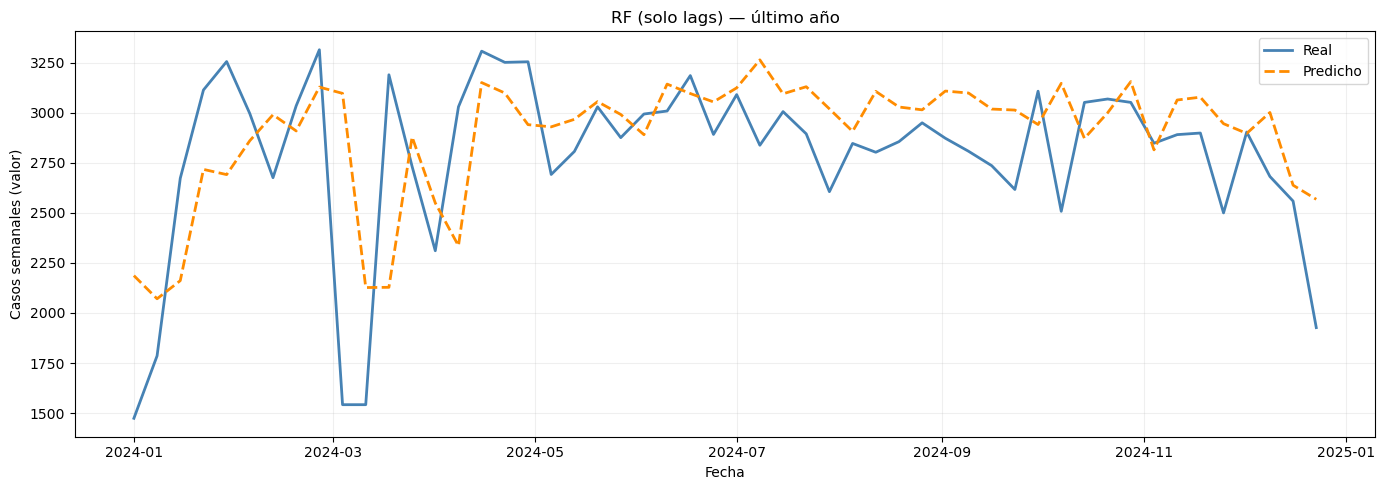

In [82]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,           # sin tope (puedes poner 20 si quieres más regularización)
    min_samples_split=5,     # controla sobreajuste
    min_samples_leaf=5,       # hojas no tan pequeñas
    max_features='sqrt',      # robusto
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF Baseline - solo lags]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")


### RF Model with sin + cos

[RF + seno/cos]
Train -> MAE=141.51  RMSE=206.44
Test  -> MAE=282.30  RMSE=391.10


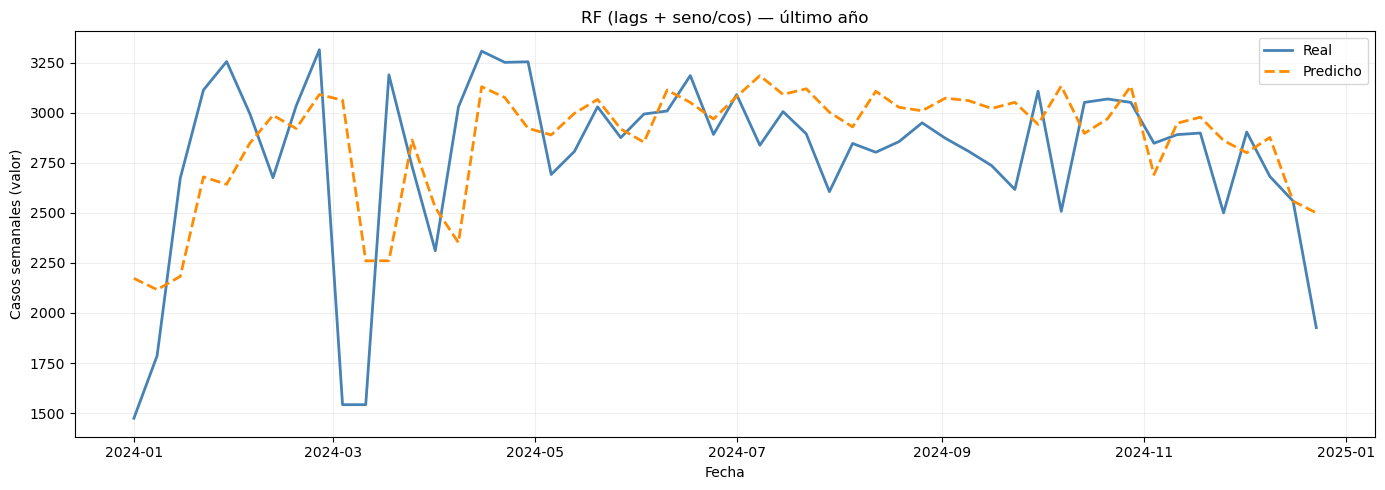

In [83]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

rf_seno = RandomForestRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + seno/cos]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos) — último año")


### Covid RF Model

[RF + COVID continuo]
Train -> MAE=143.87  RMSE=211.24
Test  -> MAE=281.50  RMSE=390.65


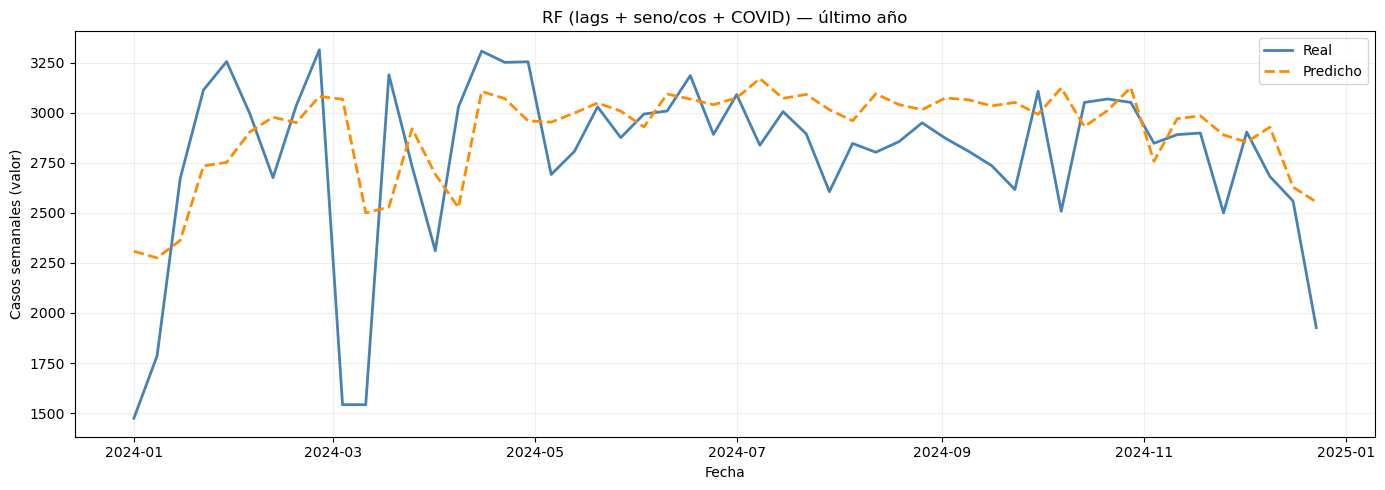

In [84]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

rf_covid = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + COVID continuo]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos + COVID) — último año")


### RF Model + rolling

[RF + rolling]
Train -> MAE=123.19  RMSE=185.52
Test  -> MAE=263.05  RMSE=362.84


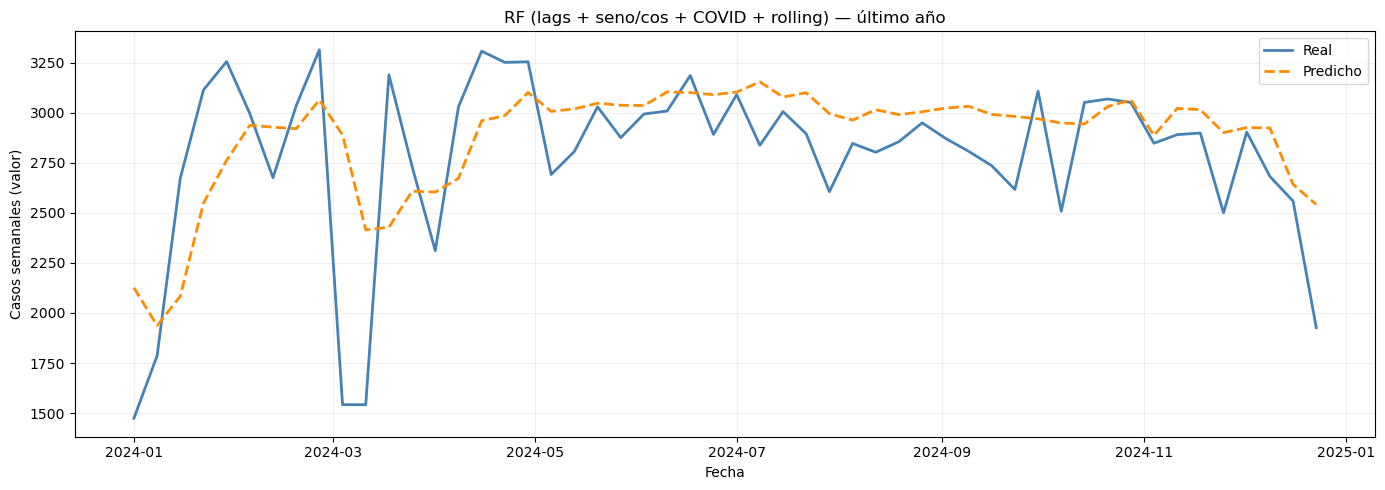

In [85]:

df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

rf_roll = RandomForestRegressor(
    n_estimators=900,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + rolling]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (lags + seno/cos + COVID + rolling) — último año")


### RF + tendencia y dummies (2020-2022)

[RF + tendencia + años]
Train -> MAE=128.33  RMSE=191.99
Test  -> MAE=260.51  RMSE=365.02


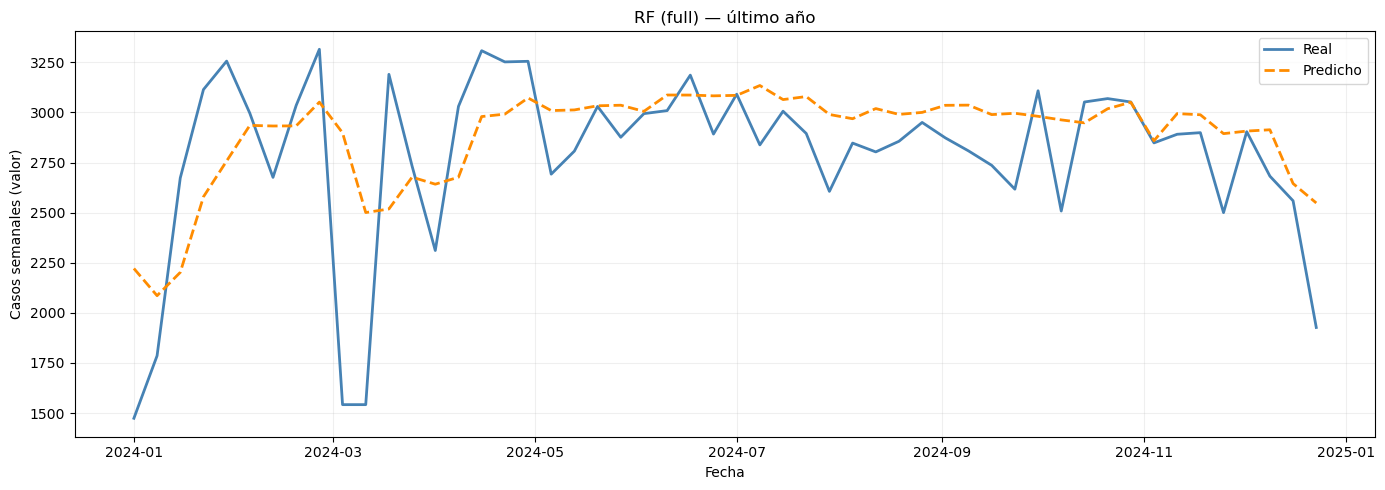

In [86]:

df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

rf_full = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,          # si ves sobreajuste, pon 20
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_tr)
mae_te, rmse_te = eval_mae_rmse(y_test,  y_pred_te)

print(f"[RF + tendencia + años]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plot_last_year(test_df, y_test, y_pred_te, "RF (full) — último año")


### Walk forward

In [ ]:
def walk_forward_cv(df, features, target, n_splits=4):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    maes, rmses = [], []
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        mae, rmse = eval_mae_rmse(y_te, y_hat)
        maes.append(mae); rmses.append(rmse)

    print(f"Walk-forward ({n_splits}): MAE={np.mean(maes):.2f} ± {np.std(maes):.2f} | RMSE={np.mean(rmses):.2f} ± {np.std(rmses):.2f}")


print("Base Model")
walk_forward_cv(df_rf4, features_lags, target, n_splits=4)

print("SIN/COS Model")
walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4)

print("Covid Model")
walk_forward_cv(df_rf3, features_covid, target, n_splits=4)

print("Rolling Model")
walk_forward_cv(df_rf4, features_rolling, target, n_splits=4)

print("Tendencia Model")
walk_forward_cv(df_rf5, features_full, target, n_splits=4)


Base Model
Walk-forward (4): MAE=316.18 ± 51.98 | RMSE=384.36 ± 56.22
SIN/COS Model
Walk-forward (4): MAE=328.86 ± 59.21 | RMSE=395.75 ± 63.06
Covid Model
Walk-forward (4): MAE=377.47 ± 46.58 | RMSE=446.88 ± 40.00
Rolling Model
Walk-forward (4): MAE=271.02 ± 46.20 | RMSE=332.44 ± 47.76
Tendencia Model
Walk-forward (4): MAE=316.09 ± 50.71 | RMSE=378.28 ± 48.06


[RF Full + RollingLong]
Train -> MAE=93.58  RMSE=144.75
Test  -> MAE=228.27  RMSE=321.18


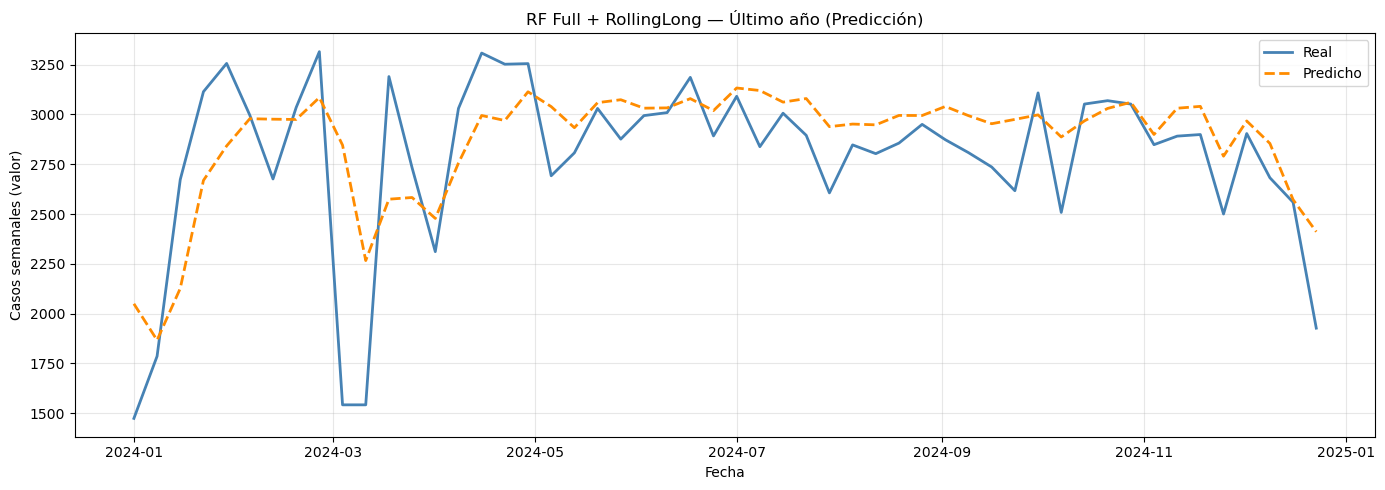

In [88]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

rf_full_long = RandomForestRegressor(
    n_estimators=1200,      # más árboles = mejor estabilidad
    max_depth=18,           # control de complejidad
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

mae_tr, rmse_tr = eval_mae_rmse(y_train, y_pred_train)
mae_te, rmse_te = eval_mae_rmse(y_test, y_pred_test)

print(f"[RF Full + RollingLong]")
print(f"Train -> MAE={mae_tr:.2f}  RMSE={rmse_tr:.2f}")
print(f"Test  -> MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")

plt.figure(figsize=(14,5))
plt.plot(test_df["fecha"], y_test, label="Real", color="steelblue", linewidth=2)
plt.plot(test_df["fecha"], y_pred_test, "--", label="Predicho", color="darkorange", linewidth=2)
plt.title("RF Full + RollingLong — Último año (Predicción)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [89]:
print("Longer Rolling Model")
walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4)

Longer Rolling Model
Walk-forward (4): MAE=272.96 ± 47.83 | RMSE=326.08 ± 50.56


## Modelo 5: RF + XGBoost

[0]	train-rmse:515.17667	valid-rmse:719.88136
[200]	train-rmse:43.21146	valid-rmse:324.06133
[337]	train-rmse:26.71641	valid-rmse:323.15940
[XGBoost Full + RollingLong]
Train -> MAE=12.31  RMSE=26.72
Test  -> MAE=239.17  RMSE=323.16


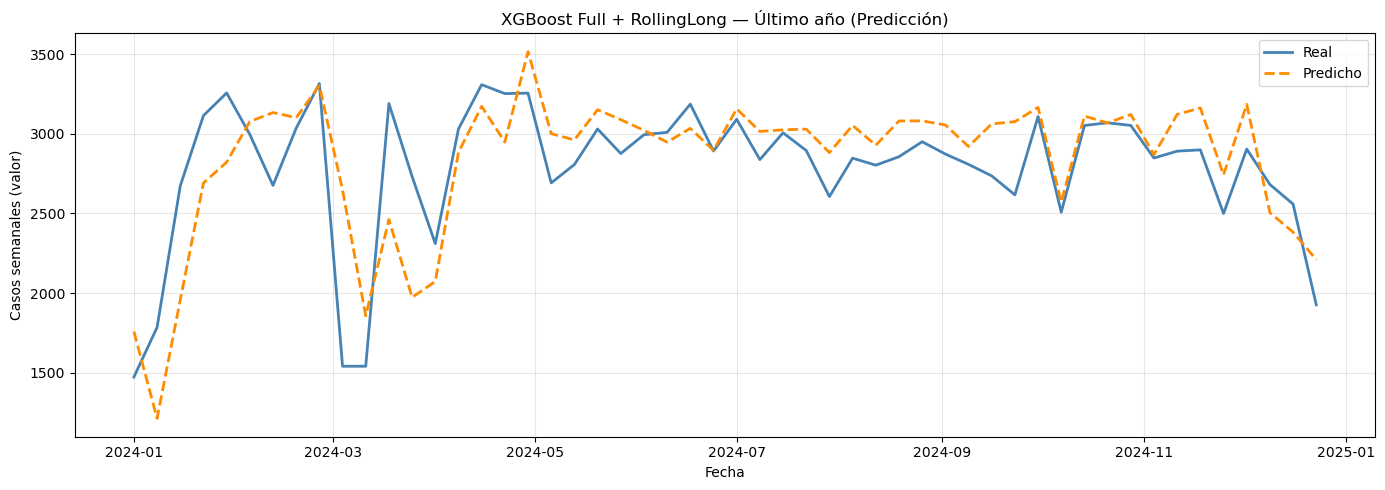


🔎 Top 10 variables más importantes:
                feature          gain
8             rolling_4  1.366973e+06
0                 lag_1  1.147971e+05
13              trend_8  9.758113e+04
7   semanas_desde_covid  6.584941e+04
10           rolling_12  4.632332e+04
11           rolling_26  3.489629e+04
9             rolling_8  2.725838e+04
4                lag_52  2.621088e+04
14             año_2020  2.490264e+04
12            tendencia  2.408671e+04


In [ ]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,              
    "max_depth": 10,
    "min_child_weight": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1,
    "alpha": 1,
    "gamma": 0.1,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"[XGBoost Full + RollingLong]")
print(f"Train -> MAE={mae_train:.2f}  RMSE={rmse_train:.2f}")
print(f"Test  -> MAE={mae_test:.2f}  RMSE={rmse_test:.2f}")

plt.figure(figsize=(14,5))
plt.plot(test_df["fecha"], y_test, label="Real", color="steelblue", linewidth=2)
plt.plot(test_df["fecha"], y_pred_test, "--", label="Predicho", color="darkorange", linewidth=2)
plt.title("XGBoost Full + RollingLong — Último año (Predicción)")
plt.xlabel("Fecha"); plt.ylabel("Casos semanales (valor)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

importance = model_xgb_full.get_score(importance_type="gain")
importance_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "gain": list(importance.values())
}).sort_values(by="gain", ascending=False)

print("\nTop 10 variables más importantes:")
print(importance_df.head(10))

In [91]:
print("XGB + Rolling Model")
walk_forward_cv(df_xgb, features_full_long, target, n_splits=4)

XGB + Rolling Model
Walk-forward (4): MAE=272.96 ± 47.83 | RMSE=326.08 ± 50.56
